# Faster R-CNN & Mask R-CNN — WaRP-D Object Detection
**Author:** El Mehdi Ziate

WaRP-D is the detection subset of WaRP: same images as WaRP-C but with
bounding box annotations. The task is to locate AND classify each waste item.

We train:
- **Faster R-CNN**: two-stage detector, outputs boxes + class labels

## Setup

In [6]:
import sys, json, time
from pathlib import Path

import numpy as np
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

root = Path.cwd()
while not (root / 'Models').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
WARP_D_DIR = root / 'Dataset/raw/WaRP-D'   
NUM_CLASSES = 29  # 28 WaRP classes + 1 background
print(f'Device: {DEVICE}')


Device: cuda


## Dataset

WaRP-D annotations are in YOLO format: one `.txt` per image.
Each line: `class_id  x_center  y_center  width  height` (normalised 0-1).

We convert to the format torchvision expects:
`boxes` in `[x1, y1, x2, y2]` absolute pixel coordinates,
`labels` as int64 starting from 1 (0 is background).

For Mask R-CNN we also need binary masks. Since WaRP-D only has boxes
(no polygon annotations), we generate masks from the boxes: a filled
rectangle. This is a valid approximation for training Mask R-CNN when
pixel masks are unavailable. If you have WaRP-S masks, use those instead.

In [7]:
class WaRPDetectionDataset(Dataset):

    def __init__(self, root, split='train', with_mask=False,
                 warp_s_root=None, transforms=None):
        self.root        = Path(root)
        self.with_mask   = with_mask
        self.warp_s_root = Path(warp_s_root) if warp_s_root else None
        self.transforms  = transforms

        self.img_dir = self.root / split / 'images'
        self.lbl_dir = self.root / split / 'labels'

        self.imgs = sorted(self.img_dir.glob('*.jpg')) + \
                    sorted(self.img_dir.glob('*.jpeg')) + \
                    sorted(self.img_dir.glob('*.png'))

        cls_file = self.root / 'classes.txt'
        if cls_file.exists():
            self.class_names = ['background'] + cls_file.read_text().strip().split('\n')
        else:
            self.class_names = ['background'] + [f'class_{i}' for i in range(28)]

        print(f'WaRPDetection [{split}]: {len(self.imgs)} images, '
              f'{len(self.class_names)-1} classes')
        if with_mask and warp_s_root:
            print(f'  Masks: WaRP-S SegmentationObject')
        elif with_mask:
            print(f'  Masks: box-derived (WaRP-S not provided)')

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img      = Image.open(img_path).convert('RGB')
        W, H     = img.size

        lbl_path      = self.lbl_dir / (img_path.stem + '.txt')
        boxes, labels = [], []

        if lbl_path.exists():
            for line in lbl_path.read_text().strip().split('\n'):
                if not line.strip():
                    continue
                parts  = line.split()
                cls_id = int(parts[0]) + 1
                xc, yc, w, h = map(float, parts[1:5])
                x1 = max(0.0, (xc - w / 2) * W)
                y1 = max(0.0, (yc - h / 2) * H)
                x2 = min(W,   (xc + w / 2) * W)
                y2 = min(H,   (yc + h / 2) * H)
                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    labels.append(cls_id)

        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes  = torch.tensor(boxes,  dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels,
                  'image_id': torch.tensor([idx])}

        if self.with_mask:
            seg_path = (
                self.warp_s_root / 'SegmentationObject' / (img_path.stem + '.png')
                if self.warp_s_root else None
            )

            if seg_path and seg_path.exists():
                # Real WaRP-S instance masks
                # SegmentationObject: each unique non-zero pixel value = one object instance
                import numpy as np
                inst = np.array(Image.open(seg_path).convert('L'))  # grayscale
                instance_ids = np.unique(inst)
                instance_ids = instance_ids[instance_ids != 0]      # remove background

                if len(instance_ids) > 0:
                    masks = torch.stack([
                        torch.from_numpy((inst == iid).astype(np.uint8))
                        for iid in instance_ids
                    ])  # (N, H, W)
                else:
                    masks = torch.zeros((0, H, W), dtype=torch.uint8)
            else:
                # Fallback: box-derived masks (when WaRP-S not available)
                masks = torch.zeros((len(boxes), H, W), dtype=torch.uint8)
                for i, box in enumerate(boxes):
                    x1, y1, x2, y2 = box.int().tolist()
                    masks[i, y1:y2, x1:x2] = 1

            target['masks'] = masks

        if self.transforms:
            img, target = self.transforms(img, target)
        else:
            img = TF.to_tensor(img)

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))

## Augmentations

Detection augmentations must transform BOTH the image AND the bounding boxes.
We use a custom wrapper class for this.

Augmentations chosen for WaRP-D:
- **RandomHorizontalFlip**: bottles appear from both directions on the belt
- **ColorJitter**: industrial lighting varies across cameras
- **RandomScale**: objects appear at different distances from the camera

In [8]:
import random

class DetectionAugmentation:
    """
    Augmentation pipeline that transforms image AND bounding boxes together.
    Standard torchvision transforms only work on images — boxes would become
    misaligned after a flip or crop if not updated simultaneously.
    """

    def __init__(self, train=True):
        self.train = train
        self.color_jitter = T.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
        )

    def __call__(self, img, target):
        # Always: to tensor and normalise
        if self.train:
            # Random horizontal flip
            if random.random() > 0.5:
                img    = TF.hflip(img)
                W      = img.width if hasattr(img, 'width') else img.shape[-1]
                # Flip boxes: new_x1 = W - old_x2, new_x2 = W - old_x1
                if len(target['boxes']):
                    boxes          = target['boxes'].clone()
                    boxes[:, 0]    = W - target['boxes'][:, 2]
                    boxes[:, 2]    = W - target['boxes'][:, 0]
                    target['boxes'] = boxes
                if 'masks' in target and len(target['masks']):
                    target['masks'] = target['masks'].flip(-1)

            # Color jitter (image only — boxes unchanged)
            img = self.color_jitter(img)

        img = TF.to_tensor(img)  # (C, H, W) float in [0, 1]
        return img, target


def get_loaders(warp_d_dir, warp_s_root=None, batch_size=2, with_mask=False):
    import platform
    nw = 0 if platform.system() == 'Windows' else 2 
    print(f'Using {nw} workers for data loading')

    train_ds = WaRPDetectionDataset(
        warp_d_dir, split='train', with_mask=with_mask,
        warp_s_root=warp_s_root,
        transforms=DetectionAugmentation(train=True)
    )
    val_ds = WaRPDetectionDataset(
        warp_d_dir, split='test', with_mask=with_mask,
        warp_s_root=warp_s_root,
        transforms=DetectionAugmentation(train=False)
    )
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=nw, collate_fn=collate_fn, pin_memory=(nw > 0)
    )
    val_loader = DataLoader(
        val_ds, batch_size=1, shuffle=False,
        num_workers=nw, collate_fn=collate_fn
    )
    return train_loader, val_loader, train_ds.class_names


## Training Loop

In [9]:
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import platform

def train_one_epoch(model, loader, optimizer, device, scaler=None):
    model.train()
    total_loss = 0
    for images, targets in tqdm(loader, desc='  train', leave=False):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader, device):
    """Validation loss — used in Phase 1 (fast, no inference needed)."""
    model.train()   # train mode to get loss dict
    total_loss = 0
    for images, targets in tqdm(loader, desc='  val  ', leave=False):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        total_loss += sum(model(images, targets).values()).item()
    model.eval()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_map(model, loader, device):
    """
    mAP@50 and mAP@50:95 — used in Phase 2 to save the best model.

    mAP@50    = mean AP at IoU ≥ 0.50  (standard WaRP-D metric)
    mAP@50:95 = mean AP at IoU 0.50 to 0.95 in steps of 0.05 (COCO metric)
    """
    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox')

    for images, targets in tqdm(loader, desc='  mAP  ', leave=False):
        images = [img.to(device) for img in images]
        preds  = model(images)

        metric.update(
            [{k: v.cpu() for k, v in p.items()} for p in preds],
            [{k: v.cpu() for k, v in t.items()} for t in targets],
        )

    res = metric.compute()
    return {
        'map':    res['map'].item(),        # mAP@50:95
        'map_50': res['map_50'].item(),     # mAP@50
        'mar_1':  res['mar_1'].item(),      # mean recall at 1 detection per image
        'mar_10': res['mar_10'].item(),     # mean recall at 10 detections per image
    }


def train(model, train_loader, val_loader, device,
          phase1_epochs=5, phase2_epochs=10,
          backbone_lr=1e-5, head_lr=1e-4,
          save_path=None):
    """
    Two-phase training:
      Phase 1 — backbone frozen, heads only, save on best val loss (fast)
      Phase 2 — full fine-tuning, save on best mAP@50 (correct metric)

    Metrics tracked:
      train_loss : average loss per epoch
      val_loss   : validation loss (Phase 1 proxy)
      map_50     : mAP at IoU=0.50 (Phase 2, main metric)
      map        : mAP@50:95 (Phase 2, strict COCO metric)
    """
    nw     = 0 if platform.system() == 'Windows' else 2
    scaler = torch.amp.GradScaler('cuda') if device == 'cuda' else None

    history  = {
        'train_loss': [],
        'val_loss':   [],
        'map_50':     [],
        'map':        [],
    }
    best_val  = float('inf')
    best_map  = 0.0

    # ── Phase 1: frozen backbone, save on val loss ────────────────────────
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=head_lr, weight_decay=0.0005
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=phase1_epochs
    )

    print('Phase 1 — heads only (saving on best val loss)')
    for epoch in range(1, phase1_epochs + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, device, scaler)
        v_loss = evaluate_loss(model, val_loader, device)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['map_50'].append(None)
        history['map'].append(None)

        print(f'  Epoch {epoch:2d}/{phase1_epochs}  '
              f'train_loss={t_loss:.4f}  val_loss={v_loss:.4f}')

        # Save on best val loss during Phase 1
        if v_loss < best_val and save_path:
            best_val = v_loss
            torch.save(model.state_dict(), save_path)
            print(f'    Saved (val_loss={best_val:.4f})')

    # ── Phase 2: full fine-tuning, save on best mAP@50 ───────────────────
    model.unfreeze_backbone()
    optimizer = torch.optim.AdamW(
        model.get_param_groups(backbone_lr, head_lr),
        weight_decay=0.0005
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=phase2_epochs
    )

    print('\nPhase 2 — full fine-tuning (saving on best mAP@50)')
    for epoch in range(1, phase2_epochs + 1):
        t_loss  = train_one_epoch(model, train_loader, optimizer, device, scaler)
        v_loss  = evaluate_loss(model, val_loader, device)
        map_res = evaluate_map(model, val_loader, device)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['map_50'].append(map_res['map_50'])
        history['map'].append(map_res['map'])

        print(f'  Epoch {epoch:2d}/{phase2_epochs}  '
              f'train_loss={t_loss:.4f}  '
              f'val_loss={v_loss:.4f}  '
              f'mAP@50={map_res["map_50"]:.4f}  '
              f'mAP@50:95={map_res["map"]:.4f}  '
              f'mAR@10={map_res["mar_10"]:.4f}')

        # Save on best mAP@50 during Phase 2
        if map_res['map_50'] > best_map and save_path:
            best_map = map_res['map_50']
            torch.save(model.state_dict(), save_path)
            print(f'    Saved (mAP@50={best_map:.4f})')

    print(f'\nBest mAP@50 : {best_map:.4f}')
    print(f'Best val loss (Phase 1): {best_val:.4f}')
    return history

c:\Users\El Mehdi Ziate\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


## Train Faster R-CNN

In [5]:
from Models.FastRcnn import FasterRCNNWaRP

train_loader, val_loader, CLASS_NAMES = get_loaders(
    WARP_D_DIR, warp_s_root=root / 'Dataset/raw/Warp-S', batch_size=2, with_mask=False
)

faster_rcnn = FasterRCNNWaRP(num_classes=NUM_CLASSES).to(DEVICE)

history_faster = train(
    faster_rcnn, train_loader, val_loader, DEVICE,
    phase1_epochs = 5,
    phase2_epochs = 10,
    save_path     = root / 'Models/weights/faster_rcnn_warp.pth'
)


Using 0 workers for data loading
WaRPDetection [train]: 2452 images, 28 classes
WaRPDetection [test]: 522 images, 28 classes
[FasterRCNN] ResNet-50 FPN — COCO pretrained
  Classes     : 29 (28 WaRP + 1 background)
  Parameters  : 41,215,136
[FasterRCNN] Backbone frozen
Phase 1 — heads only (saving on best val loss)


  Epoch  1/5  train_loss=0.7869  val_loss=0.6302
    Saved (val_loss=0.6302)


  Epoch  2/5  train_loss=0.6685  val_loss=0.5958
    Saved (val_loss=0.5958)


  Epoch  3/5  train_loss=0.6149  val_loss=0.5632
    Saved (val_loss=0.5632)


  Epoch  4/5  train_loss=0.5794  val_loss=0.5514
    Saved (val_loss=0.5514)


...

  Epoch  6/10  train_loss=0.2705  val_loss=0.4018  mAP@50=0.5553  mAP@50:95=0.3833  mAR@10=0.6092
    Saved (mAP@50=0.5553)


  Epoch  7/10  train_loss=0.2323  val_loss=0.4126  mAP@50=0.5582  mAP@50:95=0.3859  mAR@10=0.5968
    Saved (mAP@50=0.5582)


  Epoch  8/10  train_loss=0.2051  val_loss=0.4266  mAP@50=0.5592  mAP@50:95=0.3919  mAR@10=0.6011
    Saved (mAP@50=0.5592)


  Epoch  9/10  train_loss=0.1885  val_loss=0.4296  mAP@50=0.5643  mAP@50:95=0.3980  mAR@10=0.6011
    Saved (mAP@50=0.5643)


  Epoch 10/10  train_loss=0.1768  val_loss=0.4321  mAP@50=0.5621  mAP@50:95=0.3966  mAR@10=0.5997

Best mAP@50 : 0.5643
Best val loss (Phase 1): 0.5369


## Loss Curves

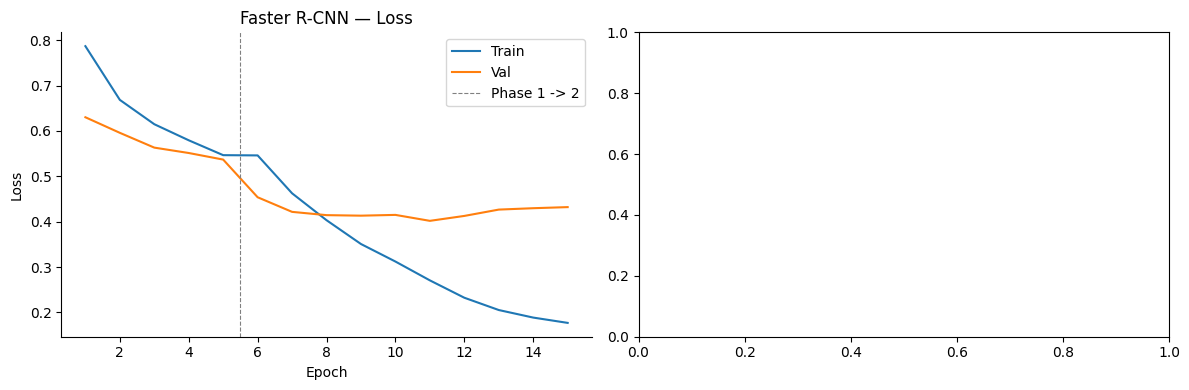

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, history, name in zip(
    axes,
    [history_faster],
    ['Faster R-CNN']
):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train')
    ax.plot(epochs, history['val_loss'],   label='Val')
    ax.axvline(5.5, color='gray', linestyle='--', linewidth=0.8,
               label='Phase 1 -> 2')
    ax.set_title(f'{name} — Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(root / 'Dataset/figures/rcnn_loss_curves.png', dpi=150)
plt.show()


## Inference Visualisation

In [10]:
import sys, gc
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

root = Path.cwd()
while not (root / 'Models').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
WARP_D_DIR  = root / 'Dataset/raw/WaRP-D'
NUM_CLASSES = 29

from Models.FastRcnn import FasterRCNNWaRP

# Load saved weights — no training, inference only
faster_rcnn = FasterRCNNWaRP(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
faster_rcnn.load_state_dict(torch.load(
    root / 'Models/weights/faster_rcnn_warp.pth',
    map_location=DEVICE, weights_only=True
))
faster_rcnn.eval()
print('Model loaded')


import torchvision.transforms.functional as TF
import platform

# Rebuild dataset (no DataLoader needed — just the dataset object)
from torch.utils.data import Dataset

# Paste your WaRPDetectionDataset class here or import it
# then:
val_ds = WaRPDetectionDataset(
    WARP_D_DIR, split='test',
    transforms=DetectionAugmentation(train=False)
)
CLASS_NAMES = val_ds.class_names
print(f'Test set: {len(val_ds)} images')

# Visualise
torch.cuda.empty_cache()
gc.collect()

Model loaded
WaRPDetection [test]: 522 images, 28 classes
Test set: 522 images


138

WaRPDetection [test]: 522 images, 28 classes


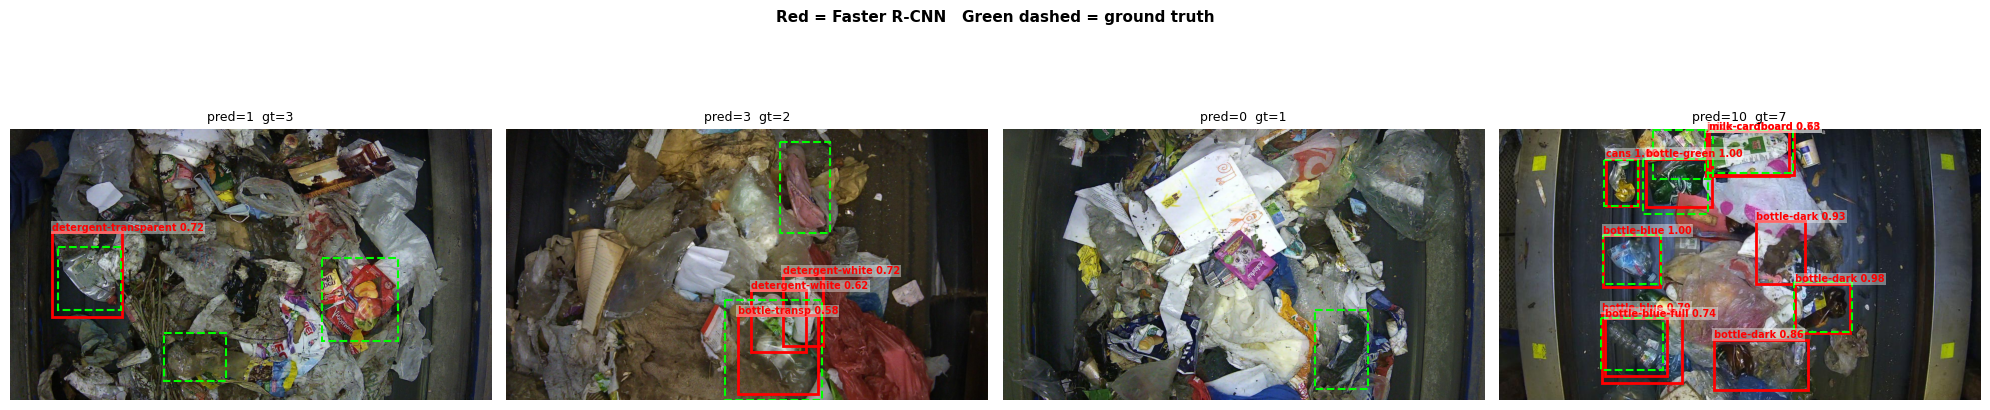

Saved → c:\Users\El Mehdi Ziate\Desktop\Waste-Classification\Dataset\figures\faster_rcnn_predictions.png


In [11]:
# Clear GPU memory first
torch.cuda.empty_cache()
import gc
gc.collect()

@torch.no_grad()
def visualize_predictions(model, dataset, class_names, device,
                          n=4, score_thresh=0.5):
    model.eval()
    torch.cuda.empty_cache()

    assert len(dataset) > 0, "Dataset is empty"
    n = min(n, len(dataset))

    fig, axes = plt.subplots(1, n, figsize=(n * 5, 5))
    if n == 1:
        axes = [axes]

    indices = np.random.choice(len(dataset), n, replace=False)

    for ax, idx in zip(axes, indices):
        img_tensor, target = dataset[idx]

        # Move to device, run inference, immediately move results back to CPU
        with torch.no_grad():
            img_gpu = img_tensor.unsqueeze(0).to(device)  # add batch dim
            pred    = model(img_gpu)[0]
            # Pull everything to CPU immediately to free GPU memory
            pred    = {k: v.cpu() for k, v in pred.items()}
            del img_gpu
            torch.cuda.empty_cache()

        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)

        keep = pred['scores'] >= score_thresh
        for box, label, score in zip(
            pred['boxes'][keep],
            pred['labels'][keep],
            pred['scores'][keep]
        ):
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            ))
            ax.text(x1, max(y1 - 4, 0),
                    f'{class_names[label]} {score:.2f}',
                    color='red', fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.4, pad=1, linewidth=0))

        for box in target['boxes']:
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=1.5, edgecolor='lime', facecolor='none',
                linestyle='--'
            ))

        ax.set_title(f'pred={int(keep.sum())}  gt={len(target["boxes"])}',
                     fontsize=9)
        ax.axis('off')

    fig.suptitle('Red = Faster R-CNN   Green dashed = ground truth',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    save_path = root / 'Dataset/figures/faster_rcnn_predictions.png'
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


torch.cuda.empty_cache()
gc.collect()

val_ds = WaRPDetectionDataset(
    WARP_D_DIR, split='test',
    transforms=DetectionAugmentation(train=False)
)
visualize_predictions(faster_rcnn, val_ds, CLASS_NAMES, DEVICE, n=4)

## mAP Evaluation

In [13]:
# pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

val_loader, _, CLASS_NAMES = get_loaders(
    WARP_D_DIR,
    warp_s_root = root / 'Dataset/raw/Warp-S',
    batch_size  = 1,   # batch_size=1 for inference — safer on memory
    with_mask   = False
)

# swap — get_loaders returns (train, val) but we only need val
_, val_loader, CLASS_NAMES = get_loaders(
    WARP_D_DIR,
    warp_s_root = root / 'Dataset/raw/Warp-S',
    batch_size  = 1,
    with_mask   = False
)

print(f'Val loader: {len(val_loader.dataset)} images')
@torch.no_grad()
def compute_map(model, loader, device, score_thresh=0.5):
    """
    Compute mAP@50 and mAP@50:95 using torchmetrics.
    These are the standard COCO detection metrics.
    mAP@50    = mean AP at IoU threshold 0.50
    mAP@50:95 = mean AP averaged over IoU 0.50 to 0.95 (stricter)
    """
    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox')

    for images, targets in loader:
        images = [img.to(device) for img in images]
        preds  = model(images)

        # torchmetrics expects list of dicts
        pred_list = [{
            'boxes':  p['boxes'].cpu(),
            'scores': p['scores'].cpu(),
            'labels': p['labels'].cpu(),
        } for p in preds]

        tgt_list = [{
            'boxes':  t['boxes'].cpu(),
            'labels': t['labels'].cpu(),
        } for t in targets]

        metric.update(pred_list, tgt_list)

    results = metric.compute()
    return results


print('Computing mAP — Faster R-CNN')
map_faster = compute_map(faster_rcnn, val_loader, DEVICE)
print(f'  mAP@50    : {map_faster["map_50"]:.4f}')
print(f'  mAP@50:95 : {map_faster["map"]:.4f}')



Using 0 workers for data loading
WaRPDetection [train]: 2452 images, 28 classes
WaRPDetection [test]: 522 images, 28 classes
Using 0 workers for data loading
WaRPDetection [train]: 2452 images, 28 classes
WaRPDetection [test]: 522 images, 28 classes
Val loader: 522 images
Computing mAP — Faster R-CNN
  mAP@50    : 0.5611
  mAP@50:95 : 0.3967
